# MovieLens 1M Matrix Factorization

This notebook reads artifacts produced by `python -m scripts.run_pipeline`.
It does not retrain or retune any model.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from utils.data_loader import load_movielens

ROOT = Path.cwd()
REPORTS = ROOT / "reports"
PROCESSED = ROOT / "processed"

def load_json(path):
    return json.loads(path.read_text(encoding="utf-8"))

data = load_movielens(ROOT / "data")
train = pd.read_csv(PROCESSED / "train_ratings.csv")
validation = pd.read_csv(PROCESSED / "validation_ratings.csv")
test = pd.read_csv(PROCESSED / "test_ratings.csv")
ranking_train = pd.read_csv(PROCESSED / "ranking_train_ratings.csv")
ranking_targets = pd.read_csv(PROCESSED / "ranking_targets.csv")

metrics = load_json(REPORTS / "model_metrics.json")
bias_tuning = load_json(REPORTS / "bias_baseline_tuning.json")
item_knn_tuning = load_json(REPORTS / "item_knn_tuning.json")
ranking_protocol = load_json(REPORTS / "ranking_protocol.json")
ranking_metrics = load_json(REPORTS / "ranking_metrics.json")
evaluated_users = load_json(REPORTS / "evaluated_users.json")

svd_tuning = pd.read_json(REPORTS / "svd_tuning.json")
pmf_tuning = pd.read_json(REPORTS / "pmf_tuning.json")
ranking_results = pd.read_csv(REPORTS / "ranking_results.csv")
factor_interpretation = pd.read_csv(
    REPORTS / "pmf_factor_interpretation.csv"
)
factor_genre_profiles = pd.read_csv(
    REPORTS / "pmf_factor_genre_profiles.csv"
)
similarities = pd.read_csv(REPORTS / "pmf_movie_similarities.csv")
evaluated = pd.DataFrame(evaluated_users)

## 1. Project goal

Compare BiasBaseline, residualized ItemKNN, SVD, and PMF under two
explicitly different evaluation protocols.

- RMSE is pointwise rating-prediction accuracy on the deterministic
  interaction split.
- HitRate, NDCG, and MRR measure held-out next-positive recovery under a
  temporal leave-one-positive-out protocol.

These are different tasks, so rating RMSE is not presented as Top-K
recommendation accuracy.

## 2. MovieLens EDA and Insights

MovieLens 1M is sparse, user activity is heterogeneous, movie popularity
has a long tail, and ratings are skewed toward higher values. These
properties motivate regularization and careful held-out evaluation.

,metric,value
0,ratings,1.000209e+06
1,users,6.040000e+03
2,rated_movies,3.706000e+03
3,matrix_sparsity,9.573532e-01
4,median_user_activity,9.600000e+01
5,median_movie_popularity,1.235000e+02


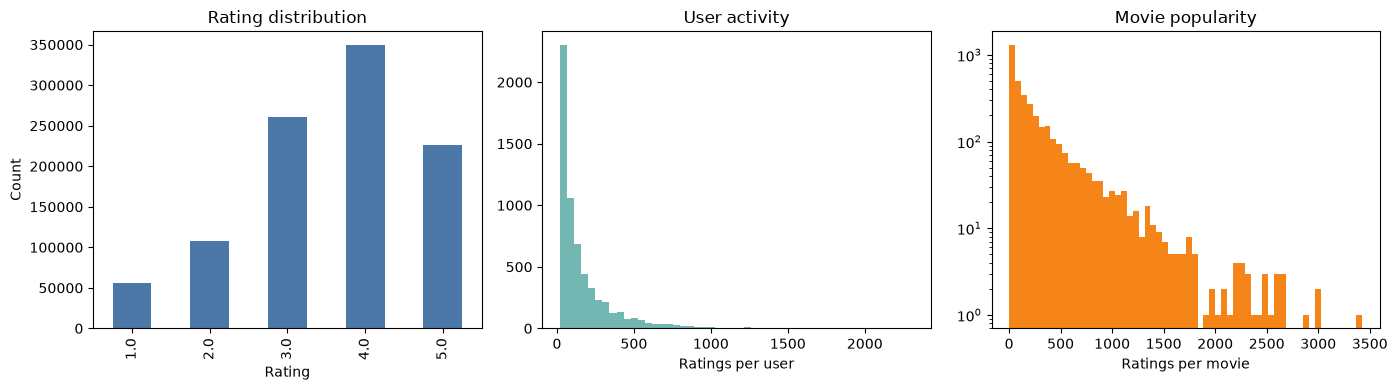

In [2]:
rating_counts = data.ratings["rating"].value_counts().sort_index()
user_activity = data.ratings.groupby("user_id").size()
movie_popularity = data.ratings.groupby("movie_id").size()
sparsity = 1.0 - len(data.ratings) / (
    data.users["user_id"].nunique() * data.movies["movie_id"].nunique()
)
display(pd.DataFrame([
    {"metric": "ratings", "value": len(data.ratings)},
    {"metric": "users", "value": data.ratings["user_id"].nunique()},
    {"metric": "rated_movies", "value": data.ratings["movie_id"].nunique()},
    {"metric": "matrix_sparsity", "value": sparsity},
    {"metric": "median_user_activity", "value": user_activity.median()},
    {"metric": "median_movie_popularity", "value": movie_popularity.median()},
]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rating_counts.plot(kind="bar", ax=axes[0], color="#4c78a8")
axes[0].set(title="Rating distribution", xlabel="Rating", ylabel="Count")
axes[1].hist(user_activity, bins=50, color="#72b7b2")
axes[1].set(title="User activity", xlabel="Ratings per user")
axes[2].hist(movie_popularity, bins=60, log=True, color="#f58518")
axes[2].set(title="Movie popularity", xlabel="Ratings per movie")
fig.tight_layout()
plt.show()

## 3. Rating-prediction split

The pointwise protocol preserves the deterministic 70/15/15
interaction split. Validation selects hyperparameters and stopping; test
rows remain untouched until the final train-plus-validation refit.

In [3]:
display(pd.DataFrame([
    {"split": "train", "rows": len(train)},
    {"split": "validation", "rows": len(validation)},
    {"split": "test", "rows": len(test)},
]))
display(metrics["split"])

,split,rows
0,train,705806
1,validation,147201
2,test,147202


{'train_ratio': 0.7,
 'validation_ratio': 0.15,
 'test_ratio': 0.15,
 'actual_counts': {'train': 705806, 'validation': 147201, 'test': 147202}}

## 4. Bias baseline

BiasBaseline is a regularized ablation:
`global_mean + user_bias + item_bias`. Its regularization is selected
from validation data rather than hard-coded from a previous run.

In [4]:
display(pd.DataFrame(bias_tuning["results"]))
print("Selected:", bias_tuning["selected"])
print("Test RMSE:", metrics["BiasBaseline_RMSE"])

,user_regularization,item_regularization,n_iterations,validation_mse,validation_rmse
0,1.0,1.0,20,0.820027,0.905553
1,2.0,2.0,20,0.819857,0.905459
2,5.0,5.0,20,0.820151,0.905622
3,10.0,10.0,20,0.821857,0.906564
4,20.0,20.0,20,0.827044,0.909419
5,40.0,40.0,20,0.839119,0.916034
6,80.0,80.0,20,0.862262,0.928581


Selected: {'user_regularization': 2.0, 'item_regularization': 2.0, 'n_iterations': 20, 'validation_mse': 0.8198565204045031, 'validation_rmse': 0.9054592869944529}
Test RMSE: 0.9078097662922908


## 5. Item-kNN neighborhood collaborative filtering

ItemKNN subtracts the fitted bias baseline, computes sparse item residual
vectors, applies cosine significance shrinkage, and keeps pairs with at
least three common users. Prediction uses signed similarities in the
numerator and absolute similarities in the denominator. The global
top-k list is intersected with the user's fitted history; an empty
intersection falls back exactly to BiasBaseline.

In [5]:
item_results = pd.DataFrame(item_knn_tuning["results"])
display(item_results.sort_values(["validation_rmse", "k", "shrinkage"]).head(9))
print("Selected:", item_knn_tuning["selected"])
print("Test RMSE:", metrics["ItemKNN_RMSE"])
print("Neighbor diagnostics:", item_knn_tuning["final_refit"]["diagnostics"])

,k,shrinkage,min_common,validation_mse,validation_rmse
8,80,100.0,3,0.751759,0.867040
5,80,50.0,3,0.755316,0.869089
2,80,10.0,3,0.771397,0.878292
7,40,100.0,3,0.776173,0.881007
4,40,50.0,3,0.782128,0.884380
1,40,10.0,3,0.805781,0.897653
6,20,100.0,3,0.821682,0.906467
3,20,50.0,3,0.829216,0.910613
0,20,10.0,3,0.857278,0.925893


Selected: {'k': 80, 'shrinkage': 100.0, 'min_common': 3, 'validation_mse': 0.7517586090141275, 'validation_rmse': 0.8670401426774469}
Test RMSE: 0.8588447991354637
Neighbor diagnostics: {'stored_neighbor_count': 274545, 'similarities_finite': True, 'minimum_similarity': -0.09016324404620857, 'maximum_similarity': 0.377741504898087, 'minimum_common_users': 3, 'self_neighbor_count': 0, 'deterministic_ordering_verified': True}


## 6. SVD methodology and tuning

SVD factorizes a user-mean-centered sparse matrix with a regularized item
residual bias. Raw predictions are retained for ranking; clipping is used
only for rating evaluation and display.

In [6]:
display(svd_tuning.sort_values("validation_rmse").head(10))
print("Selected SVD parameters:", metrics["svd_best_params"])

,n_factors,item_bias_regularization,validation_rmse
7,20,5,0.896209
2,20,0,0.896270
12,20,10,0.896792
8,40,5,0.897119
3,40,0,0.897152
13,40,10,0.897733
17,20,20,0.898262
6,10,5,0.898446
1,10,0,0.898577
11,10,10,0.898989


Selected SVD parameters: {'n_factors': 20, 'item_bias_regularization': 5.0}


## 7. PMF methodology and tuning

PMF learns user/item biases and latent interactions with seeded SGD. The
preserved grid searches 96/112/128 factors and factor regularization
0.05/0.06/0.07 at learning rate 0.006 and bias regularization 0.02.

In [7]:
display(pmf_tuning.sort_values("validation_rmse"))
print("Selected PMF parameters:", metrics["pmf_best_params"])

,n_factors,learning_rate,factor_regularization,bias_regularization,best_epoch,validation_rmse,epochs_run,seconds,hit_epoch_cap,hit_factor_boundary
7,128,0.006,0.06,0.02,53,0.849353,61,30.189,False,True
6,128,0.006,0.05,0.02,40,0.849747,48,26.883,False,True
4,112,0.006,0.06,0.02,53,0.849830,61,28.214,False,False
1,96,0.006,0.06,0.02,53,0.850033,61,25.048,False,False
8,128,0.006,0.07,0.02,68,0.850417,70,38.585,False,True
3,112,0.006,0.05,0.02,41,0.850464,49,23.291,False,False
5,112,0.006,0.07,0.02,68,0.850715,70,34.107,False,False
0,96,0.006,0.05,0.02,40,0.850756,48,21.007,False,False
2,96,0.006,0.07,0.02,68,0.850899,70,33.926,False,False


Selected PMF parameters: {'n_factors': 128, 'learning_rate': 0.006, 'factor_regularization': 0.06, 'bias_regularization': 0.02, 'selected_epoch': 53, 'validation_rmse': 0.8493525385856628}


## 8. Convergence, regularization and stopping

PMF tuning restores the best validation checkpoint. The final production
refit uses the selected epoch count on train plus validation without a
validation holdout. Ranking evaluation trains a separate PMF copy for
exactly the same frozen epoch count and never tunes against ranking targets.

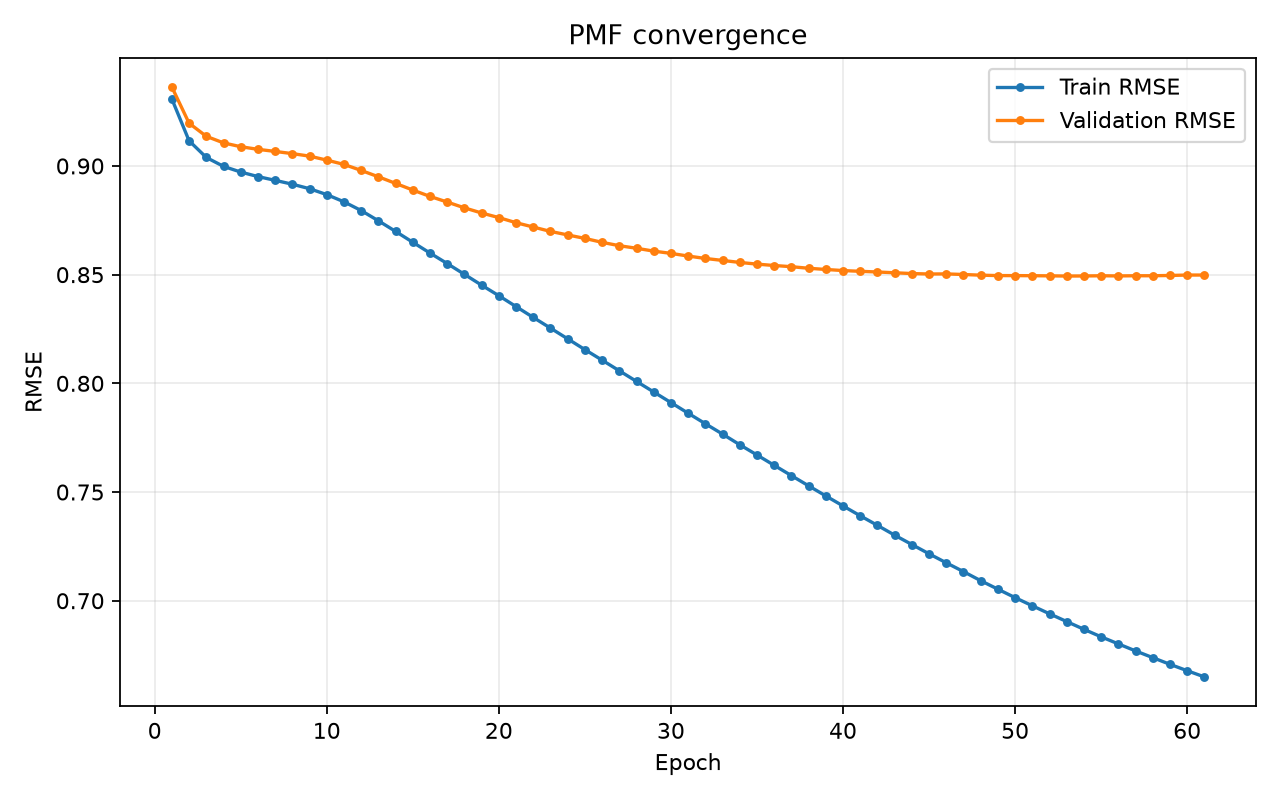

Final refit epochs: 53
Search diagnostics: {'selected_at_factor_boundary': True, 'selected_at_epoch_boundary': False, 'selected_early_stopping_triggered': True, 'search_max_factors': 128, 'search_max_epochs': 70}


In [8]:
display(Image(filename=str(REPORTS / "pmf_convergence.png")))
pmf_metadata = load_json(REPORTS / "pmf_factors" / "metadata.json")
print("Final refit epochs:", pmf_metadata["config"]["epochs"])
print("Search diagnostics:", metrics["pmf_search_diagnostics"])

## 9. Rating-prediction results

All four models use the same untouched rating test rows. The table reports
pointwise MSE/RMSE only. Pairwise booleans are generated from the actual
metrics; no comparison outcome is assumed in advance.

,model,mse,rmse
0,BiasBaseline,0.824119,0.907810
1,ItemKNN,0.737614,0.858845
2,SVD,0.793518,0.890796
3,PMF,0.712165,0.843899


SVD_beats_ItemKNN             False
PMF_beats_ItemKNN              True
ItemKNN_beats_BiasBaseline     True
dtype: bool

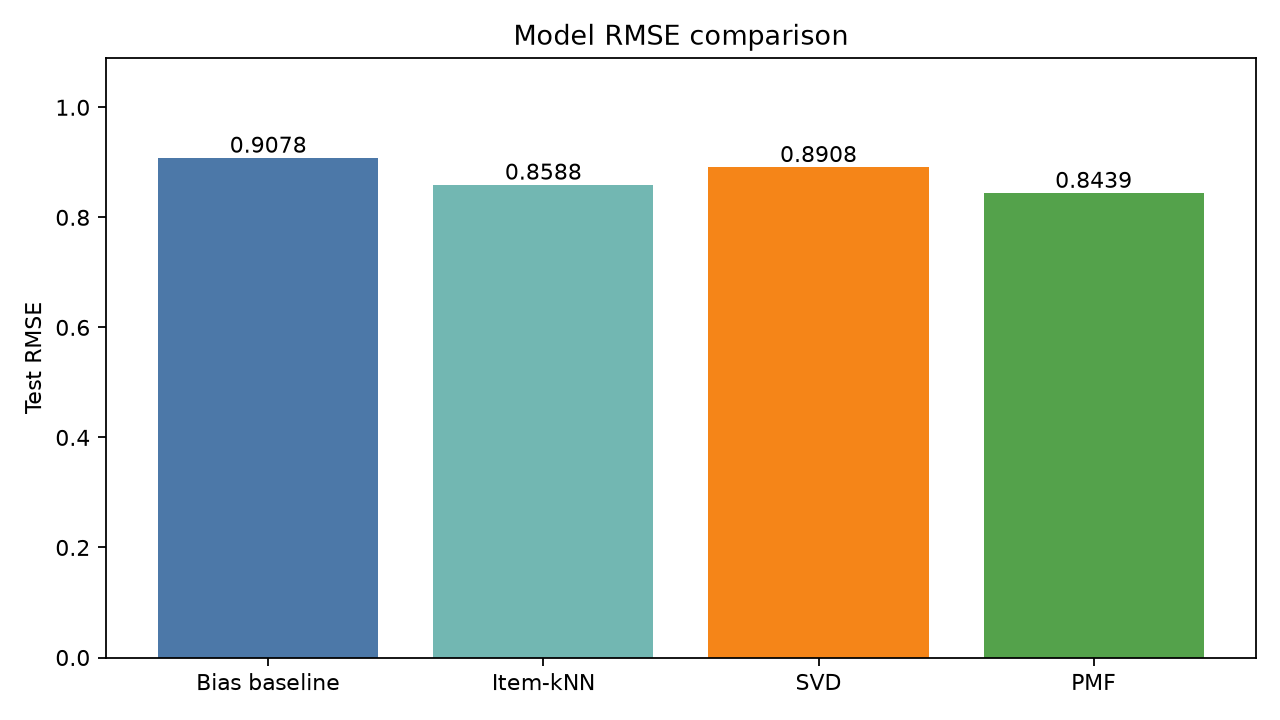

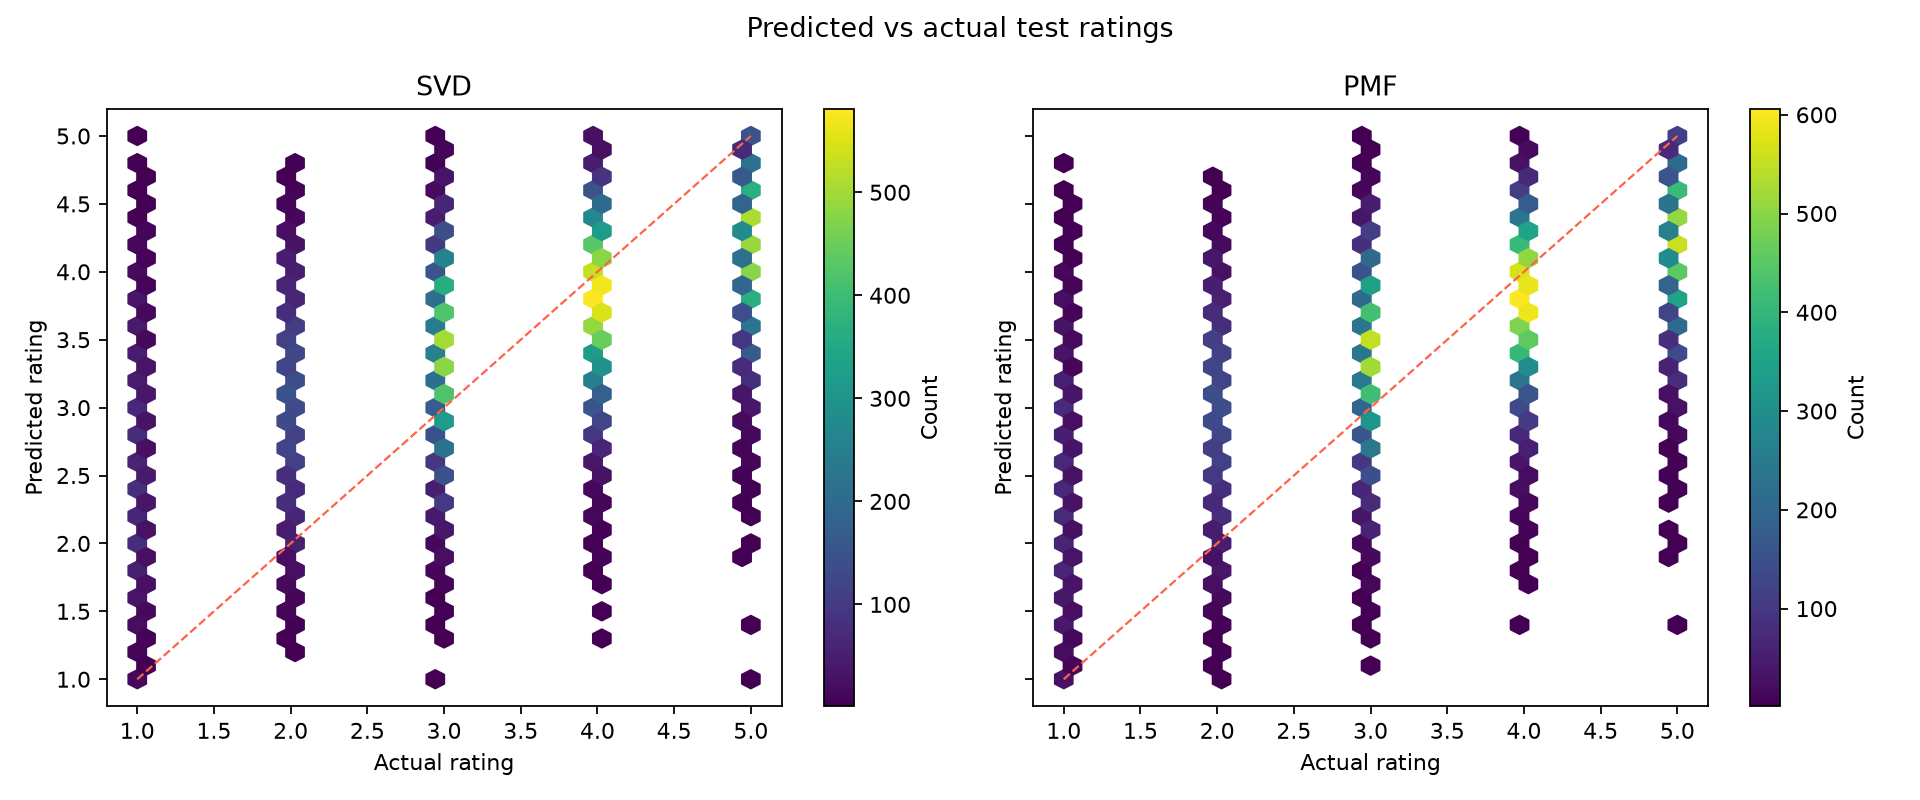

In [9]:
rating_table = pd.DataFrame([
    {"model": "BiasBaseline", "mse": metrics["BiasBaseline_MSE"], "rmse": metrics["BiasBaseline_RMSE"]},
    {"model": "ItemKNN", "mse": metrics["ItemKNN_MSE"], "rmse": metrics["ItemKNN_RMSE"]},
    {"model": "SVD", "mse": metrics["SVD_MSE"], "rmse": metrics["SVD_RMSE"]},
    {"model": "PMF", "mse": metrics["PMF_MSE"], "rmse": metrics["PMF_RMSE"]},
])
display(rating_table)
display(pd.Series({
    "SVD_beats_ItemKNN": metrics["SVD_beats_ItemKNN"],
    "PMF_beats_ItemKNN": metrics["PMF_beats_ItemKNN"],
    "ItemKNN_beats_BiasBaseline": metrics["ItemKNN_beats_BiasBaseline"],
}))
display(Image(filename=str(REPORTS / "rmse_comparison.png")))
display(Image(filename=str(REPORTS / "predicted_vs_actual.png")))

## 10. Temporal leave-one-positive-out protocol

Each eligible user contributes one known future positive: the latest
rating at least 4.0, with movie ID ascending as the same-timestamp
tie-break. Ranking history is strictly `timestamp < target_timestamp`;
same-timestamp and later interactions are excluded. Users need at least
20 prior interactions, and targets need at least 10 ranking-training
interactions.

Candidate movies are the full ranking-training-supported catalog minus
the user's prefix history. No sampled negatives are used. Unknown catalog
items are not observed negatives.

In [10]:
display(pd.Series(ranking_protocol).to_frame("value"))
display(ranking_targets.head())
print("Ranking training rows:", len(ranking_train))

,value
protocol,next-positive recovery under temporal leave-on...
positive_threshold,4.0
target_selection,latest rating >= threshold; movie_id ascending...
history_rule,timestamp < target_timestamp
same_timestamp_and_later_interactions_excluded,True
min_prior_interactions,20
min_target_item_support,10
full_catalog_candidates,True
sampled_negatives,False
unknown_items_are_observed_negatives,False


,user_id,movie_id,rating,timestamp,prior_history_count,target_item_support
0,1,48,5.0,978824351,52,368
1,2,1544,4.0,978300174,125,1196
2,3,2081,4.0,978298504,50,1009
3,5,2029,4.0,978246555,193,71
4,6,597,5.0,978239019,70,1030


Ranking training rows: 974610


## 11. Top-K ranking results

HitRate/NDCG/MRR measure next-positive recovery for the single held-out
target. Recall is not reported separately because with one target it is
identical to HitRate.

,model,eligible_user_count,mean_target_rank,median_target_rank,HitRate@5,NDCG@5,MRR@5,HitRate@10,NDCG@10,MRR@10
0,BiasBaseline,5767.0,1148.594243,934.0,0.004682,0.002093,0.001283,0.013178,0.004714,0.002291
1,ItemKNN,5767.0,1084.283510,845.0,0.002601,0.001599,0.001269,0.005375,0.002502,0.001645
2,SVD,5767.0,1097.460378,796.0,0.019421,0.011453,0.008841,0.030692,0.015065,0.010313
3,PMF,5767.0,975.601353,696.0,0.014392,0.009064,0.007338,0.026704,0.012976,0.008912


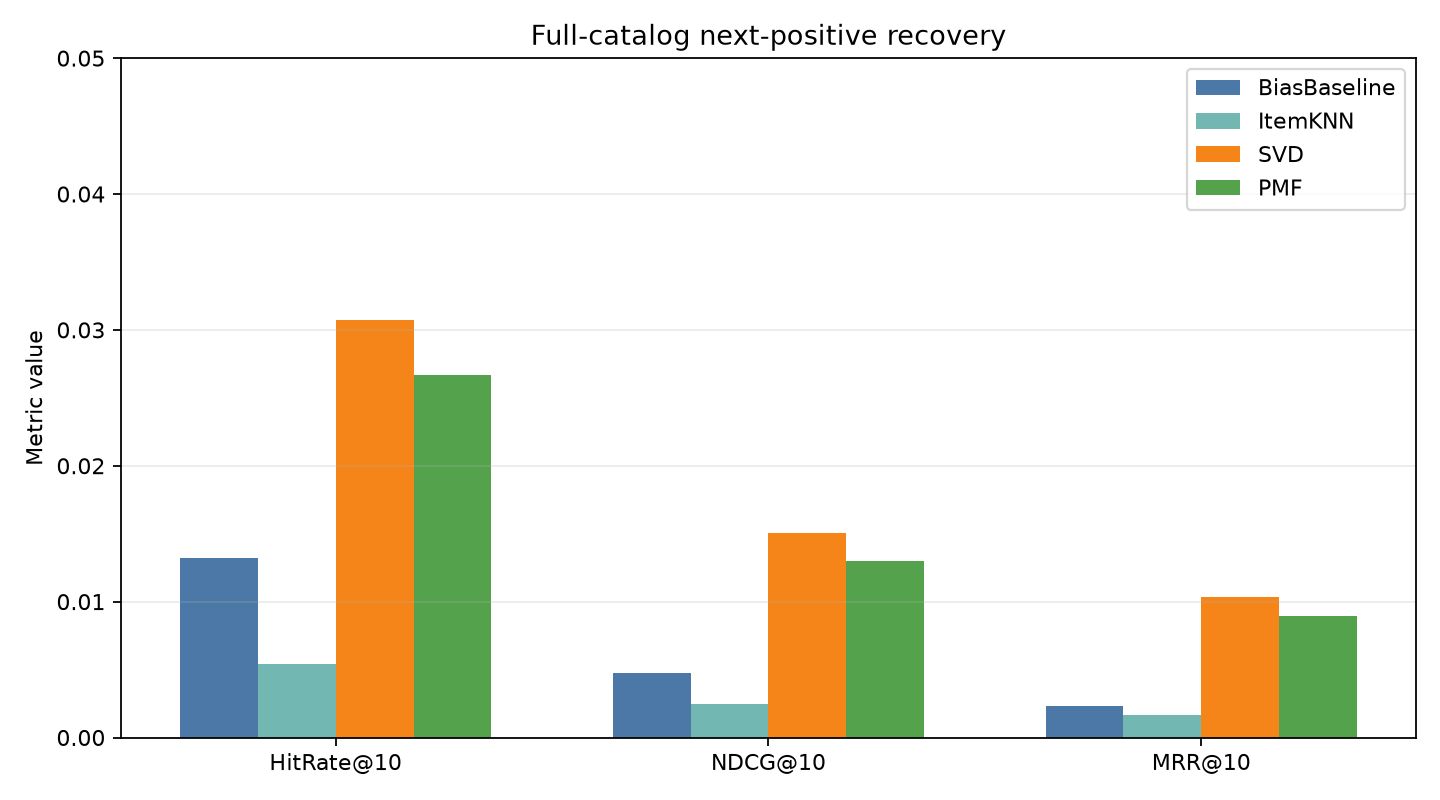

,user_id,target_movie_id,target_title,target_genres,target_rating,target_timestamp,prior_history_count,candidate_count,bias_target_rank,bias_raw_target_score,...,svd_ndcg_at_10,svd_mrr_at_10,pmf_target_rank,pmf_raw_target_score,pmf_hit_at_5,pmf_ndcg_at_5,pmf_mrr_at_5,pmf_hit_at_10,pmf_ndcg_at_10,pmf_mrr_at_10
0,1,48,Pocahontas (1995),Animation|Children's|Musical|Romance,5.0,978824351,52,3648,2668,3.204421,...,0.0,0.0,1887,3.488207,False,0.0,0.0,False,0.0,0.0
1,2,1544,"Lost World: Jurassic Park, The (1997)",Action|Adventure|Sci-Fi|Thriller,4.0,978300174,125,3575,2542,2.963435,...,0.0,0.0,1638,3.272778,False,0.0,0.0,False,0.0,0.0
2,3,2081,"Little Mermaid, The (1989)",Animation|Children's|Comedy|Musical|Romance,4.0,978298504,50,3650,972,3.851006,...,0.0,0.0,1563,3.565609,False,0.0,0.0,False,0.0,0.0
3,5,2029,Billy's Hollywood Screen Kiss (1997),Comedy|Romance,4.0,978246555,193,3507,744,3.234458,...,0.0,0.0,1150,2.974982,False,0.0,0.0,False,0.0,0.0
4,6,597,Pretty Woman (1990),Comedy|Romance,5.0,978239019,70,3630,1201,3.909067,...,0.0,0.0,88,4.262119,False,0.0,0.0,False,0.0,0.0


In [11]:
ranking_table = pd.DataFrame(ranking_metrics["models"]).T.reset_index(
    names="model"
)
display(ranking_table)
display(Image(filename=str(REPORTS / "ranking_comparison.png")))
display(ranking_results.head())

## 12. Global latent-factor interpretation

High-variance PMF factors are described from movies and genres on both
poles. Factor sign is arbitrary, so these are descriptive patterns rather
than objective semantic dimensions.

,factor_index,factor_variance,polarity,polarity_rank,movie_id,title,genres,factor_loading
0,123,0.017044,positive,1,3688,Porky's (1981),Comedy,0.644381
1,123,0.017044,positive,2,3431,Death Wish II (1982),Action|Drama,0.483069
2,123,0.017044,positive,3,3689,Porky's II: The Next Day (1983),Comedy,0.415265
3,123,0.017044,positive,4,1855,Krippendorf's Tribe (1998),Comedy,0.411035
4,123,0.017044,positive,5,3433,Death Wish 4: The Crackdown (1987),Action|Drama,0.402932
5,123,0.017044,positive,6,2411,Rocky IV (1985),Action|Drama,0.400579
6,123,0.017044,positive,7,2961,"Story of Us, The (1999)",Comedy|Drama,0.398805
7,123,0.017044,positive,8,3577,Two Moon Juction (1988),Drama,0.395567
8,123,0.017044,negative,1,2710,"Blair Witch Project, The (1999)",Horror,-0.496847
9,123,0.017044,negative,2,532,Serial Mom (1994),Comedy|Crime|Horror,-0.425156


,factor_index,polarity,genre,movie_count,genre_share,mean_factor_loading
0,10,negative,Horror,5,0.500000,-0.383474
1,10,negative,Drama,2,0.200000,-0.462993
2,10,negative,Crime,1,0.100000,-0.384618
3,10,negative,Sci-Fi,1,0.100000,-0.422868
4,10,negative,Thriller,1,0.100000,-0.384618
5,10,positive,Comedy,8,0.500000,0.457878
6,10,positive,Romance,3,0.187500,0.485245
7,10,positive,Drama,2,0.125000,0.447801
8,10,positive,Action,1,0.062500,0.450484
9,10,positive,Documentary,1,0.062500,0.432814


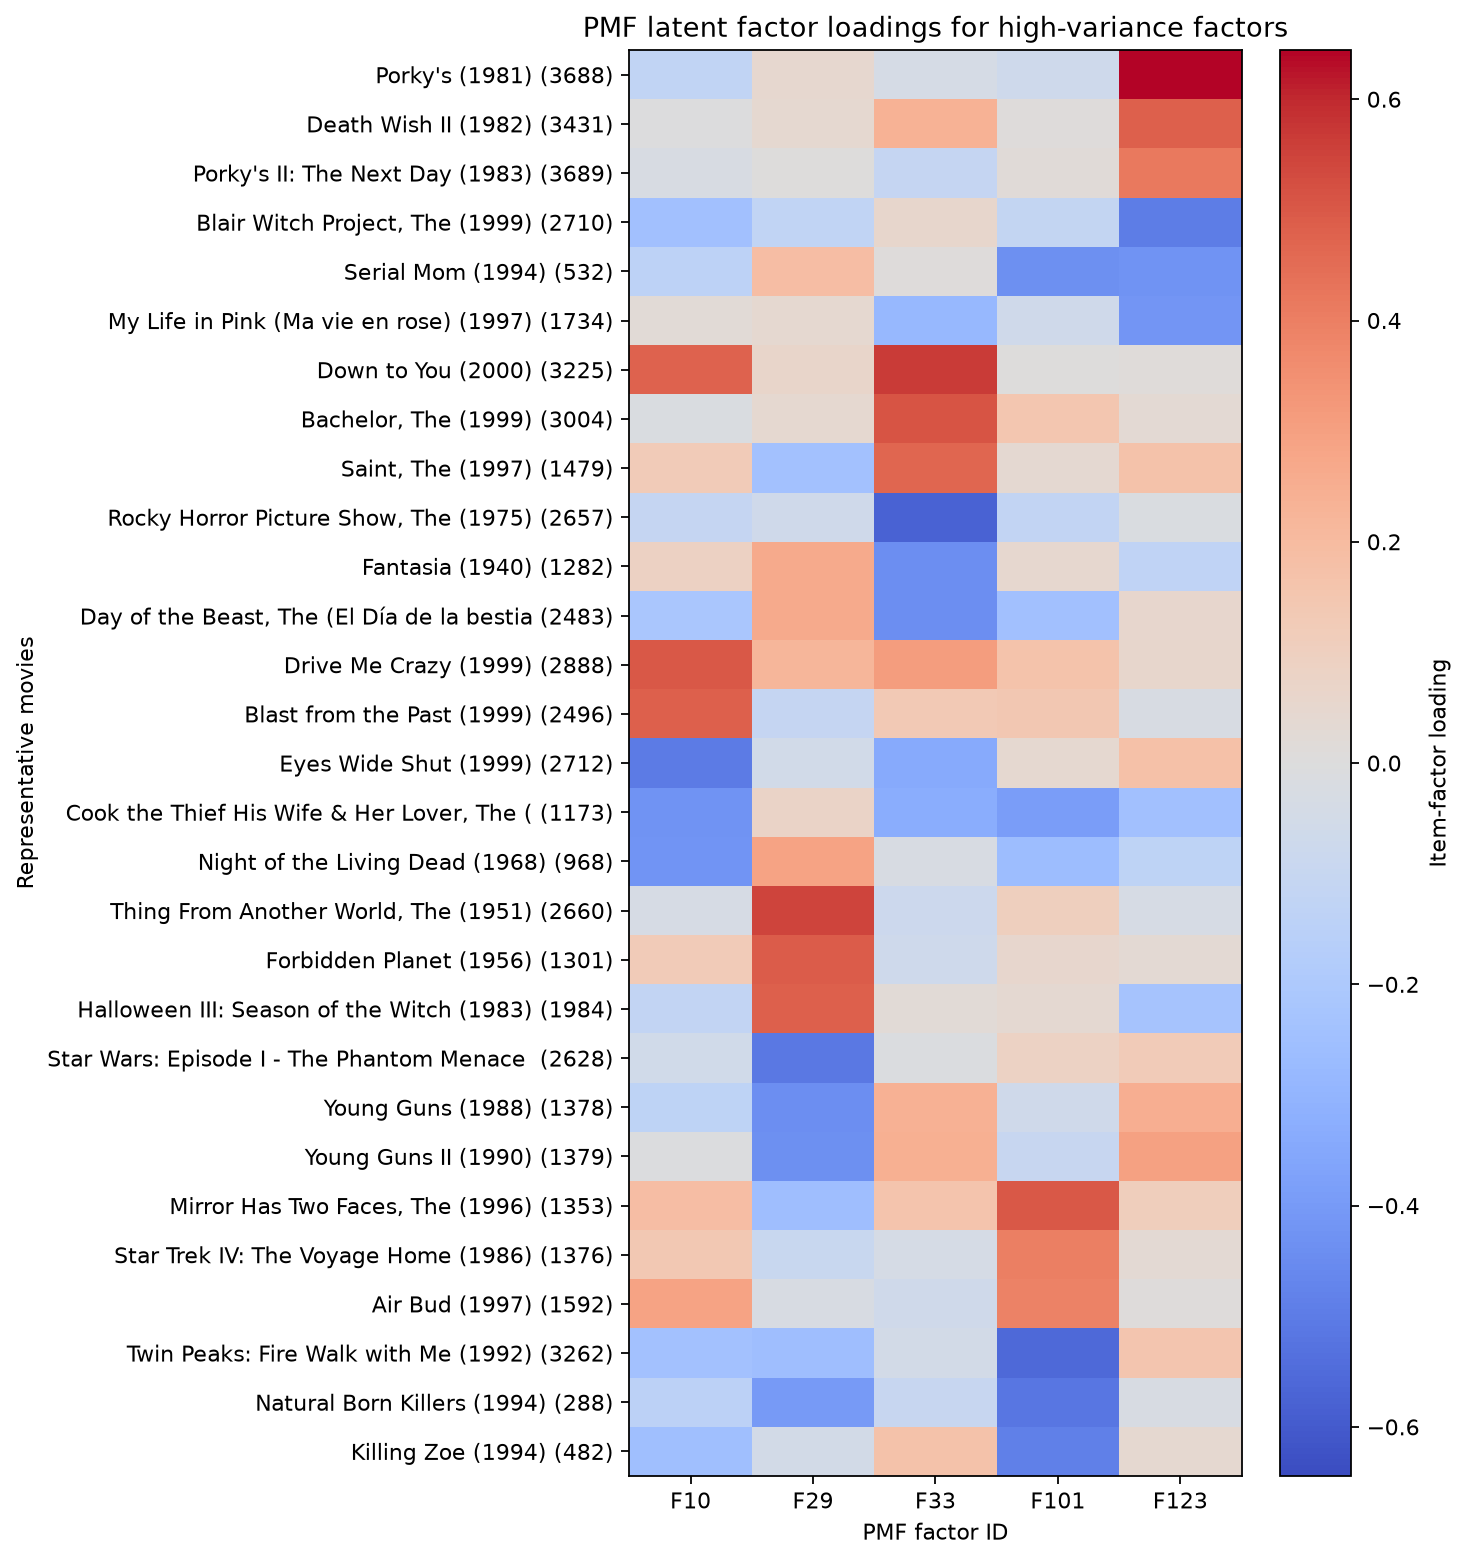

In [12]:
display(factor_interpretation.head(20))
display(factor_genre_profiles.head(20))
display(Image(filename=str(REPORTS / "pmf_latent_factor_heatmap.png")))

## 13. Movie similarity analysis

Similarity uses cosine distance between final production PMF item-factor
vectors. Self-matches are excluded and rows are deterministically sorted.

In [13]:
display(similarities.head(30))
print(
    "Similarity range:",
    similarities["cosine_similarity"].min(),
    similarities["cosine_similarity"].max(),
)

,anchor_movie_id,anchor_title,anchor_genres,similar_movie_id,similar_title,similar_genres,cosine_similarity,rank
0,2858,American Beauty (1999),Comedy|Drama,1617,L.A. Confidential (1997),Crime|Film-Noir|Mystery|Thriller,0.544902,1
1,2858,American Beauty (1999),Comedy|Drama,1222,Full Metal Jacket (1987),Action|Drama|War,0.535649,2
2,2858,American Beauty (1999),Comedy|Drama,296,Pulp Fiction (1994),Crime|Drama,0.520803,3
3,2858,American Beauty (1999),Comedy|Drama,1728,"Winter Guest, The (1997)",Drama,0.513478,4
4,2858,American Beauty (1999),Comedy|Drama,2997,Being John Malkovich (1999),Comedy,0.494339,5
5,2858,American Beauty (1999),Comedy|Drama,50,"Usual Suspects, The (1995)",Crime|Thriller,0.489682,6
6,2858,American Beauty (1999),Comedy|Drama,3317,Wonder Boys (2000),Comedy|Drama,0.478323,7
7,2858,American Beauty (1999),Comedy|Drama,1673,Boogie Nights (1997),Drama,0.473511,8
8,2858,American Beauty (1999),Comedy|Drama,3949,Requiem for a Dream (2000),Drama,0.469242,9
9,2858,American Beauty (1999),Comedy|Drama,3171,Room at the Top (1959),Drama,0.465240,10


Similarity range: 0.439644473662361 0.9368732065528416


## 14. User Case Studies

The persisted roles remain compatible with previous artifacts, but their
selection now comes from actual temporal ranking outcomes. Per-user SVD
and PMF RMSE remain secondary diagnostics.

In [14]:
case_columns = [
    "role", "user_id", "ranking_case", "ranking_target_movie_id",
    "ranking_target_title", "ranking_target_rating",
    "ranking_history_count", "ranking_candidate_count",
    "bias_target_rank", "item_knn_target_rank", "svd_target_rank",
    "pmf_target_rank", "bias_hit_at_10", "item_knn_hit_at_10",
    "svd_hit_at_10", "pmf_hit_at_10", "svd_test_rmse", "pmf_test_rmse",
]
display(evaluated[case_columns])

,role,user_id,ranking_case,ranking_target_movie_id,ranking_target_title,ranking_target_rating,ranking_history_count,ranking_candidate_count,bias_target_rank,item_knn_target_rank,svd_target_rank,pmf_target_rank,bias_hit_at_10,item_knn_hit_at_10,svd_hit_at_10,pmf_hit_at_10,svd_test_rmse,pmf_test_rmse
0,train_profile_accurate,2739,pmf_hit_at_10,2762,"Sixth Sense, The (1999)",4.0,30,3670,42,127,11,6,False,False,False,True,0.845575,0.917201
1,train_profile_less_accurate,2505,pmf_miss_at_10,317,"Santa Clause, The (1994)",4.0,31,3669,2313,83,2378,736,False,False,False,False,0.533738,0.910851
2,test_case,2210,representative_target_rank,3952,"Contender, The (2000)",5.0,24,3676,817,2106,729,696,False,False,False,False,0.918175,1.068985


## 15. Recommendation Hit vs Miss Analysis

The accurate profile is a non-extreme PMF Hit@10 near the median hit
rank. The less-accurate profile is near the median PMF miss rank. The
comparison below includes target metadata, prefix support, candidate
counts, all model ranks/Hit@10 values, pointwise RMSE diagnostics, profile
statistics, and the target-specific PMF explanation.

Score components and profile summaries may partially explain a result,
but they do not establish a causal reason for the hit or miss.

,user_id,role,ranking_case,selection_reason,train_ratings,validation_ratings,test_ratings,svd_test_rmse,pmf_test_rmse,ranking_target_movie_id,...,svd_target_rank,pmf_target_rank,bias_hit_at_10,item_knn_hit_at_10,svd_hit_at_10,pmf_hit_at_10,prefix_interactions,prefix_mean_rating,prefix_positive_share,prefix_genre_entropy
0,2739,train_profile_accurate,pmf_hit_at_10,Supported PMF Hit@10 user nearest the median n...,24,4,4,0.845575,0.917201,2762,...,11,6,False,False,False,True,30,3.400000,0.333333,3.401186
1,2505,train_profile_less_accurate,pmf_miss_at_10,Supported PMF miss user nearest the median PMF...,24,4,4,0.533738,0.910851,317,...,2378,736,False,False,False,False,31,4.096774,0.838710,3.487538



train_profile_accurate: user 2739


,target_movie_id,target_title,target_rating,target_timestamp,prior_history_count,candidate_count,bias_target_rank,item_knn_target_rank,svd_target_rank,pmf_target_rank,...,svd_raw_target_score,pmf_raw_target_score,pmf_global_mean_contribution,pmf_user_bias_contribution,pmf_item_bias_contribution,pmf_total_latent_dot_product,nearest_known_title,nearest_known_rating,nearest_known_similarity,common_genres
0,2762,"Sixth Sense, The (1999)",4.0,973224971,30,3670,42,127,11,6,...,4.154539,4.378716,3.589136,-0.149961,0.804655,0.134887,Erin Brockovich (2000),4.0,0.348877,NaN


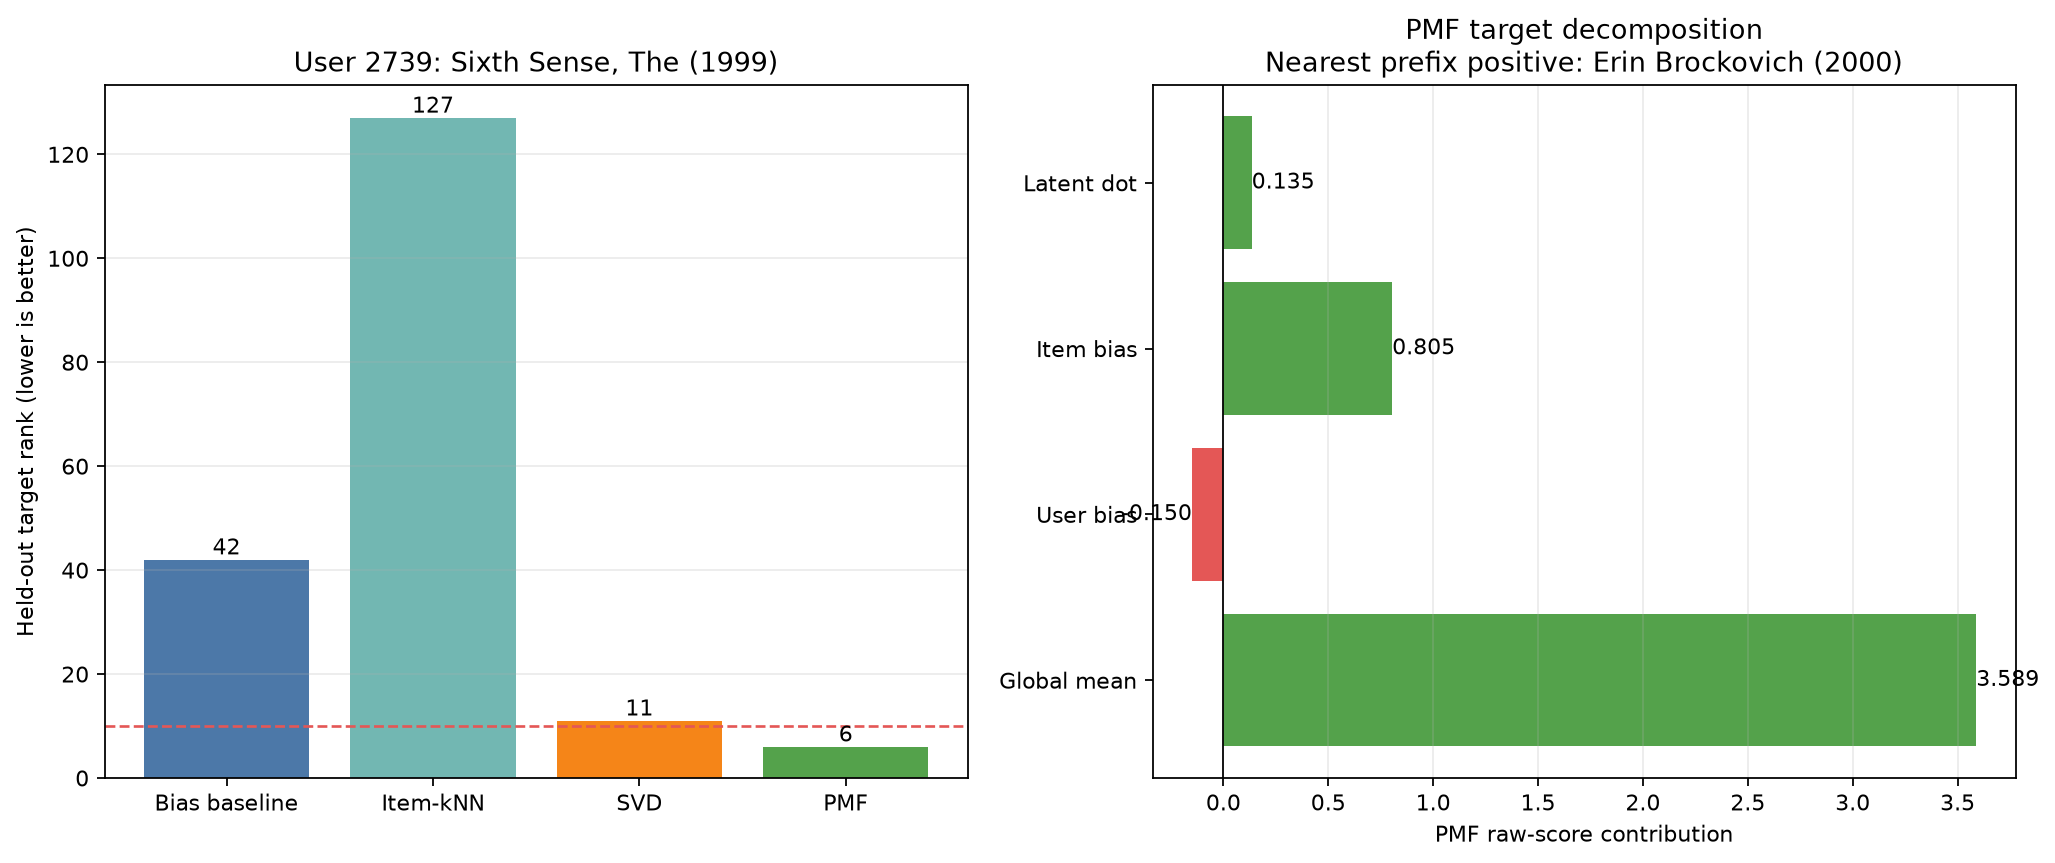


train_profile_less_accurate: user 2505


,target_movie_id,target_title,target_rating,target_timestamp,prior_history_count,candidate_count,bias_target_rank,item_knn_target_rank,svd_target_rank,pmf_target_rank,...,svd_raw_target_score,pmf_raw_target_score,pmf_global_mean_contribution,pmf_user_bias_contribution,pmf_item_bias_contribution,pmf_total_latent_dot_product,nearest_known_title,nearest_known_rating,nearest_known_similarity,common_genres
0,317,"Santa Clause, The (1994)",4.0,1007830269,31,3669,2313,83,2378,736,...,3.760245,3.906298,3.589136,0.192401,-0.454321,0.579082,Air Force One (1997),5.0,0.426195,NaN


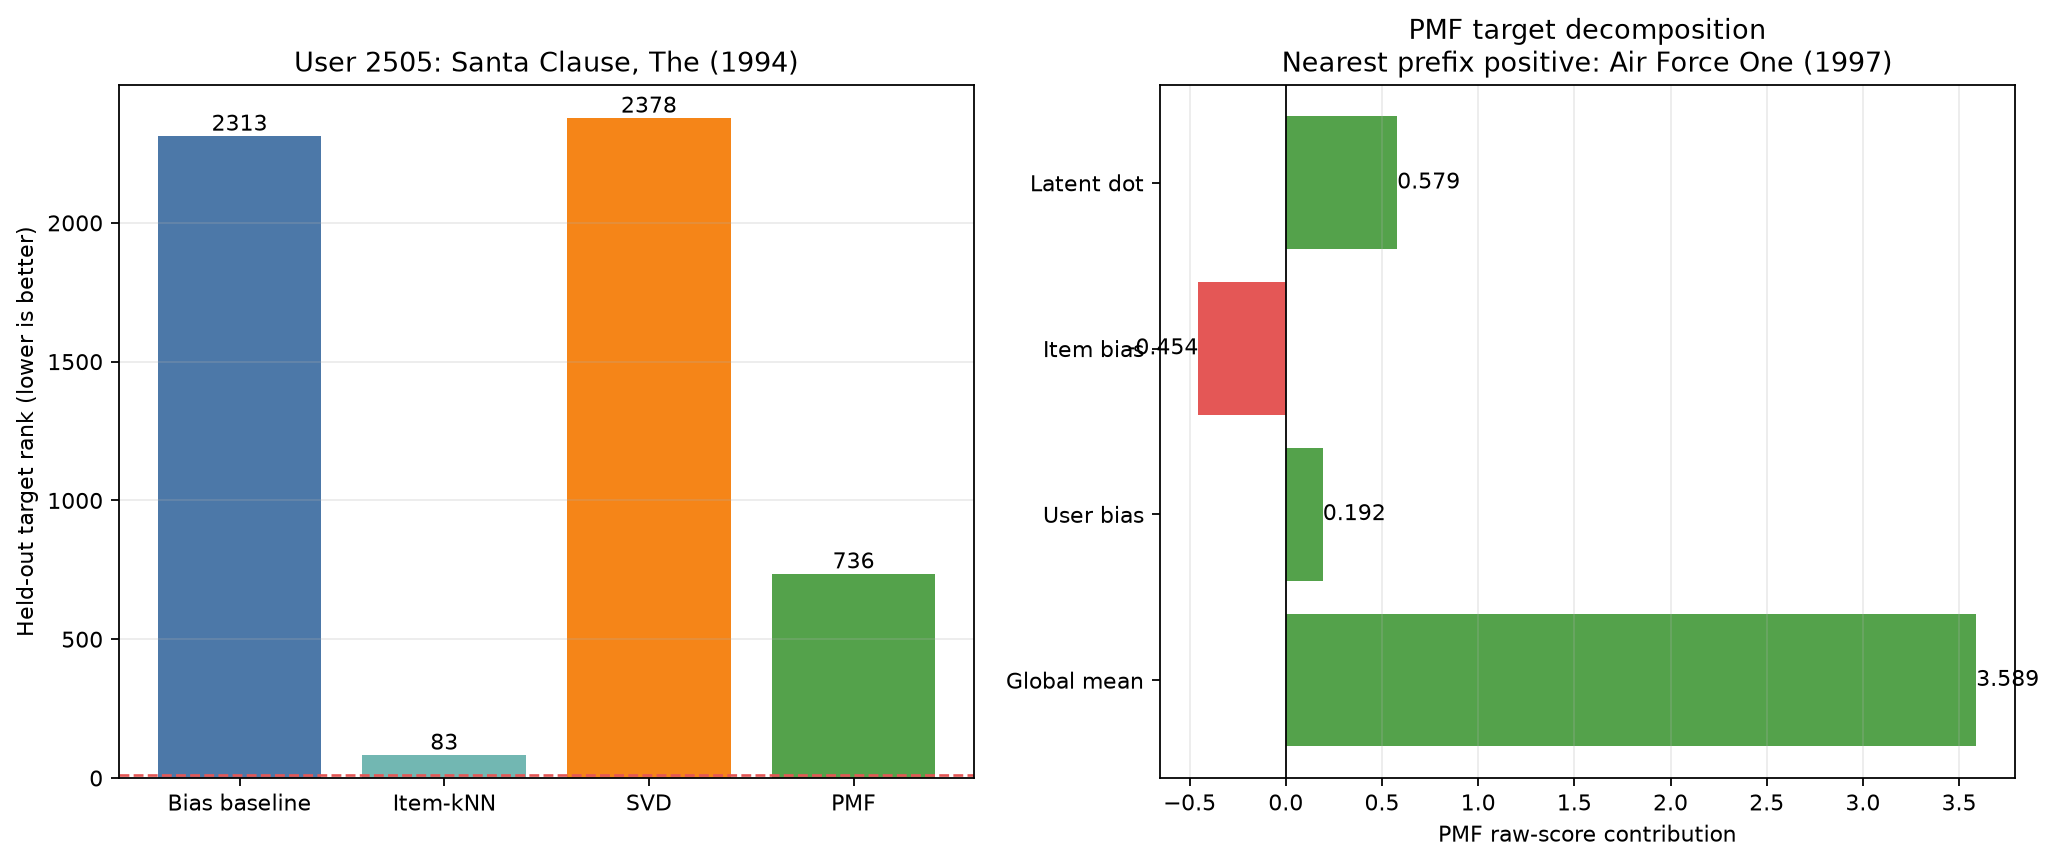

In [15]:
movie_lookup = data.movies[["movie_id", "title", "genres"]]

def genre_entropy(frame):
    genres = (
        frame.merge(movie_lookup, on="movie_id", how="left")["genres"]
        .str.split("|")
        .explode()
    )
    shares = genres.value_counts(normalize=True)
    return 0.0 if shares.empty else float(-(shares * np.log2(shares)).sum())

def prefix_stats(user_id):
    prefix = ranking_train.loc[ranking_train["user_id"].eq(user_id)]
    return {
        "user_id": user_id,
        "prefix_interactions": len(prefix),
        "prefix_mean_rating": prefix["rating"].mean(),
        "prefix_positive_share": prefix["rating"].ge(4).mean(),
        "prefix_genre_entropy": genre_entropy(prefix),
    }

hit_miss = evaluated.loc[evaluated["role"].isin([
    "train_profile_accurate", "train_profile_less_accurate"
])]
display(hit_miss.merge(
    pd.DataFrame([prefix_stats(int(user_id)) for user_id in hit_miss["user_id"]]),
    on="user_id",
    how="left",
))

for selected in hit_miss.itertuples(index=False):
    user_id = int(selected.user_id)
    case = pd.read_csv(REPORTS / f"user_{user_id}_ranking_case.csv")
    print(f"\n{selected.role}: user {user_id}")
    display(case[[
        "target_movie_id", "target_title", "target_rating",
        "target_timestamp", "prior_history_count", "candidate_count",
        "bias_target_rank", "item_knn_target_rank", "svd_target_rank",
        "pmf_target_rank", "bias_hit_at_10", "item_knn_hit_at_10",
        "svd_hit_at_10", "pmf_hit_at_10",
        "bias_raw_target_score", "item_knn_raw_target_score",
        "svd_raw_target_score", "pmf_raw_target_score",
        "pmf_global_mean_contribution", "pmf_user_bias_contribution",
        "pmf_item_bias_contribution", "pmf_total_latent_dot_product",
        "nearest_known_title", "nearest_known_rating",
        "nearest_known_similarity", "common_genres",
    ]])
    display(Image(filename=str(REPORTS / f"user_{user_id}_ranking_case.png")))

## 16. Local Recommendation Explanations

Production Top-10 recommendation explanations remain separate from the
temporal target cases. Each PMF recommendation score is decomposed into
global mean, biases, and latent dot product, with nearest known liked
movies drawn from the production user's full observed history.

User 2739 max production explanation error: 0.0


,user_id,role,recommendation_rank,movie_id,title,genres,raw_pmf_ranking_score,clipped_displayed_rating,global_mean_contribution,user_bias_contribution,...,top_factor_3_contribution,top_factor_contributions,component_sum,reconstruction_error,nearest_known_movie_id,nearest_known_title,nearest_known_genres,nearest_known_rating,nearest_known_similarity,common_genres
0,2739,train_profile_accurate,1,1198,Raiders of the Lost Ark (1981),Action|Adventure,4.463041,4.463041,3.582113,-0.173311,...,0.014194,"[{""contribution"": 0.026635882768913932, ""facto...",4.463041,0.0,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,5.0,0.687614,Action|Adventure
1,2739,train_profile_accurate,2,318,"Shawshank Redemption, The (1994)",Drama,4.420349,4.420349,3.582113,-0.173311,...,0.013942,"[{""contribution"": 0.014975625589896069, ""facto...",4.420349,0.0,2762,"Sixth Sense, The (1999)",Thriller,4.0,0.432737,NaN
2,2739,train_profile_accurate,3,2905,Sanjuro (1962),Action|Adventure,4.415621,4.415621,3.582113,-0.173311,...,-0.009105,"[{""contribution"": -0.013860299852087588, ""fact...",4.415621,0.0,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Romance|Sci-Fi|War,5.0,0.289307,Action|Adventure


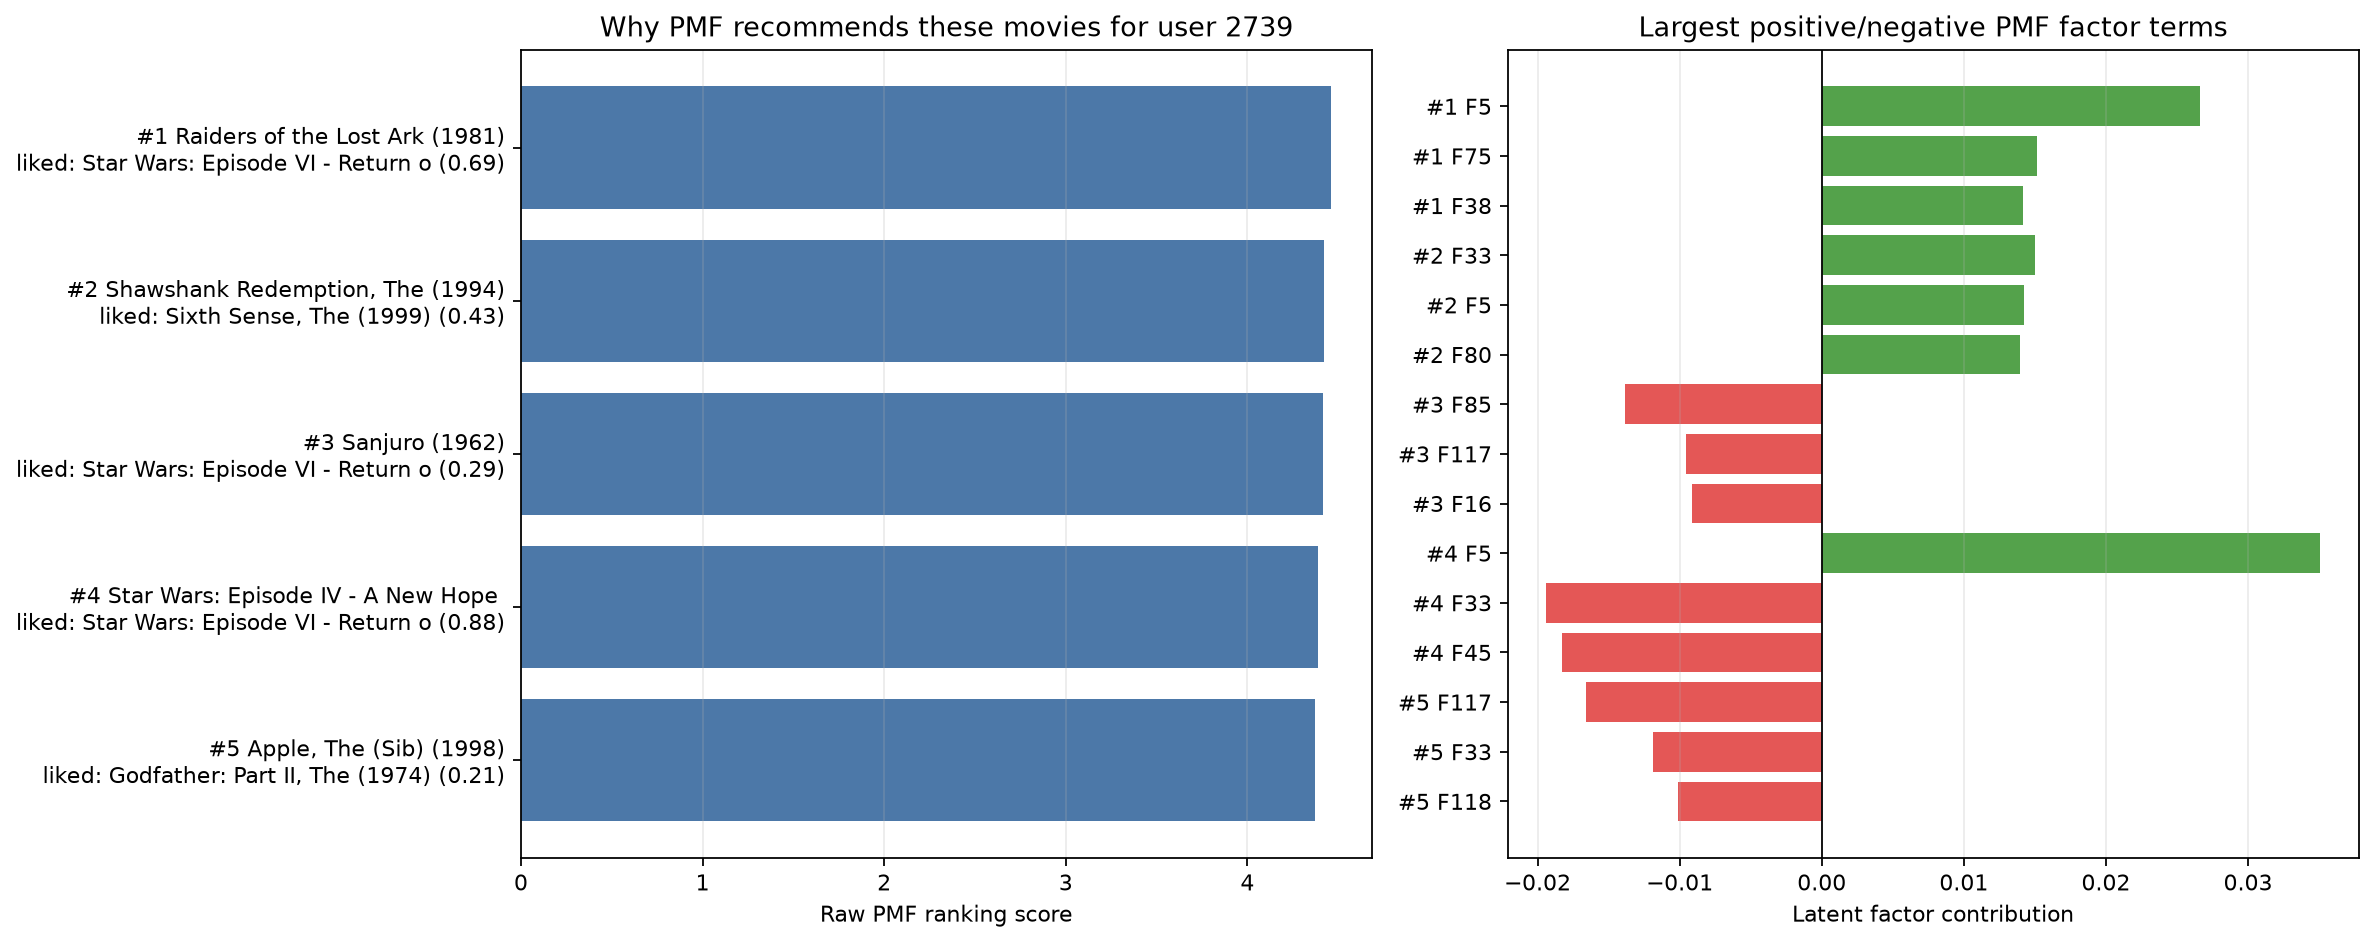

User 2505 max production explanation error: 0.0


,user_id,role,recommendation_rank,movie_id,title,genres,raw_pmf_ranking_score,clipped_displayed_rating,global_mean_contribution,user_bias_contribution,...,top_factor_3_contribution,top_factor_contributions,component_sum,reconstruction_error,nearest_known_movie_id,nearest_known_title,nearest_known_genres,nearest_known_rating,nearest_known_similarity,common_genres
0,2505,train_profile_less_accurate,1,1198,Raiders of the Lost Ark (1981),Action|Adventure,4.907337,4.907337,3.582113,0.13809,...,0.025511,"[{""contribution"": -0.030788455904713352, ""fact...",4.907337,0.0,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Fantasy|Sci-Fi,5.0,0.829514,Action|Adventure
1,2505,train_profile_less_accurate,2,2762,"Sixth Sense, The (1999)",Thriller,4.894681,4.894681,3.582113,0.13809,...,0.028094,"[{""contribution"": 0.039822109267812156, ""facto...",4.894681,0.0,356,Forrest Gump (1994),Comedy|Romance|War,5.0,0.449039,NaN
2,2505,train_profile_less_accurate,3,1036,Die Hard (1988),Action|Thriller,4.889668,4.889668,3.582113,0.13809,...,0.034552,"[{""contribution"": 0.047019024829735745, ""facto...",4.889668,0.0,589,Terminator 2: Judgment Day (1991),Action|Sci-Fi|Thriller,5.0,0.719067,Action|Thriller


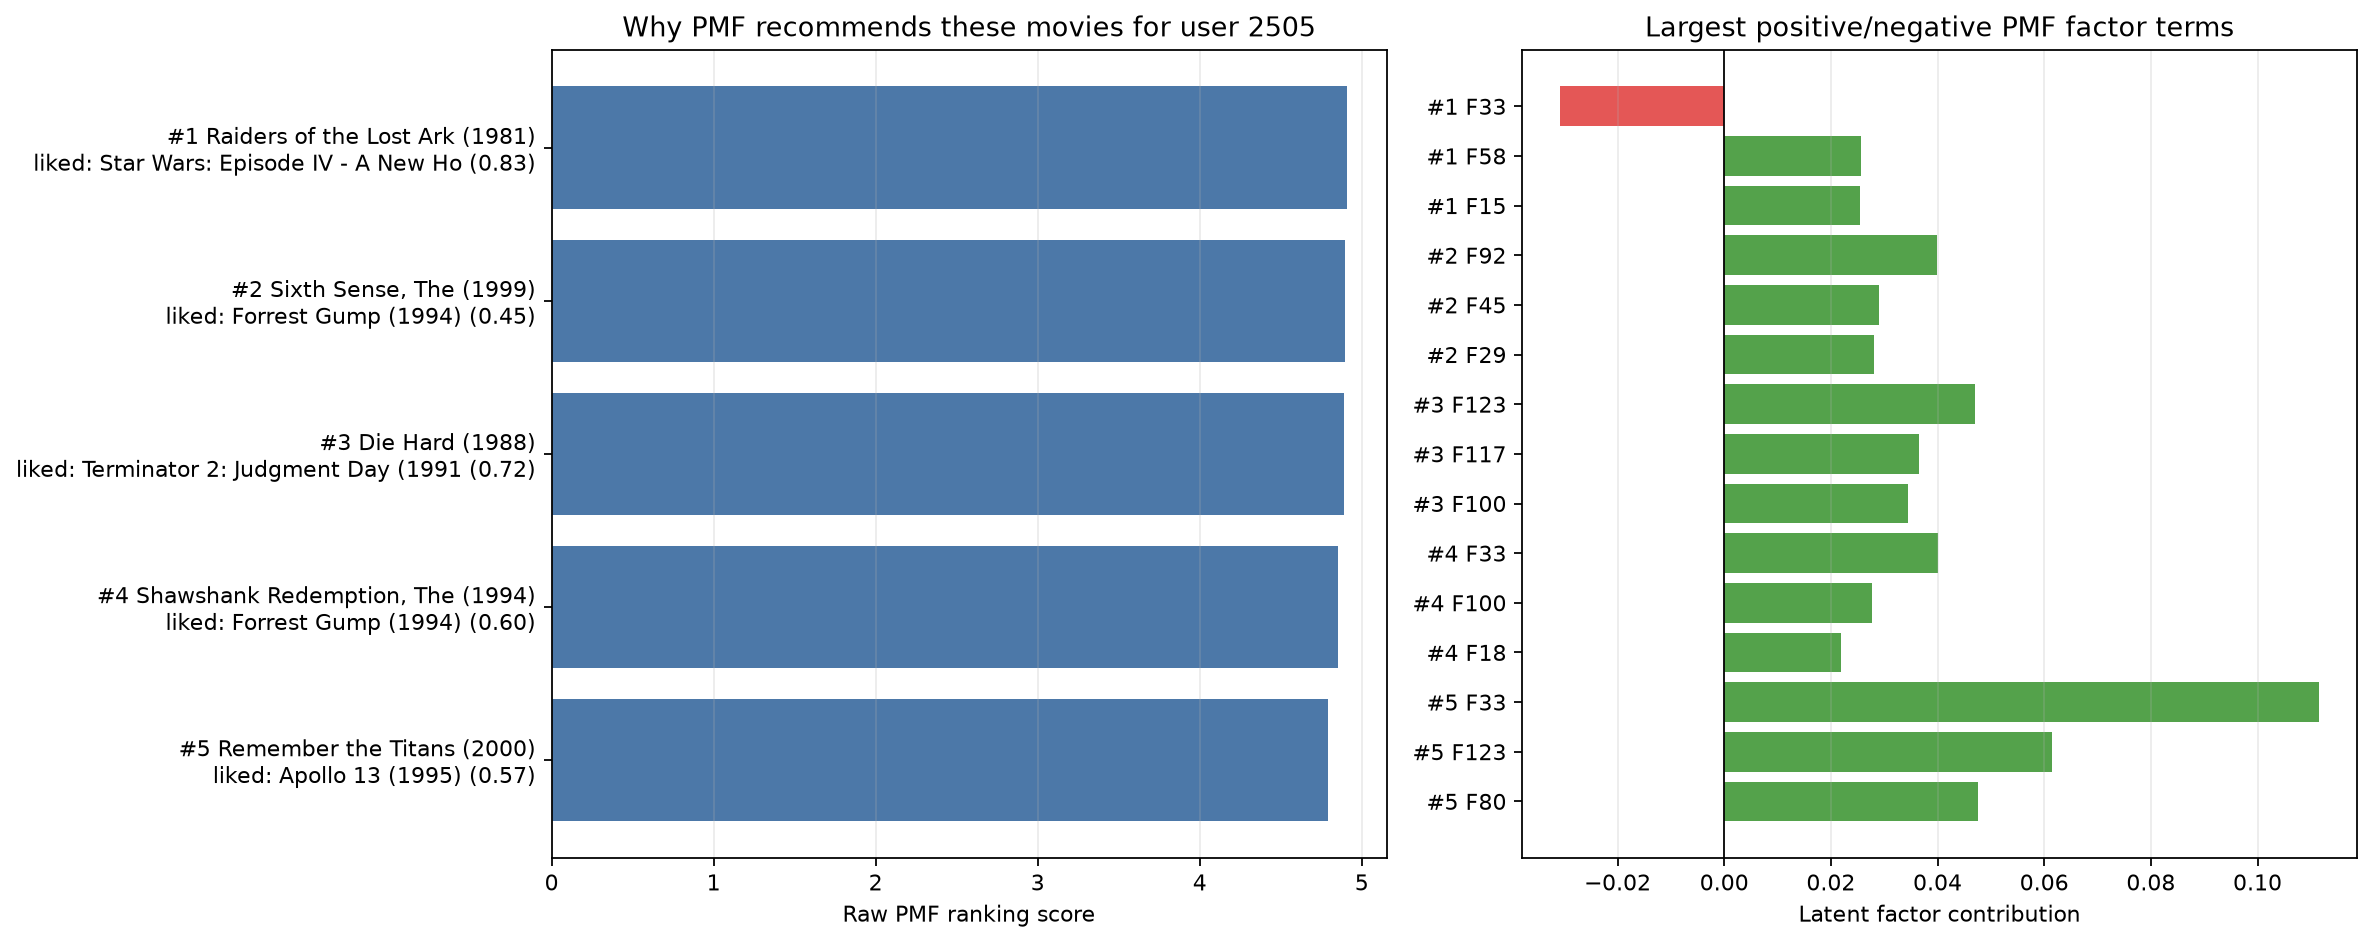

User 2210 max production explanation error: 0.0


,user_id,role,recommendation_rank,movie_id,title,genres,raw_pmf_ranking_score,clipped_displayed_rating,global_mean_contribution,user_bias_contribution,...,top_factor_3_contribution,top_factor_contributions,component_sum,reconstruction_error,nearest_known_movie_id,nearest_known_title,nearest_known_genres,nearest_known_rating,nearest_known_similarity,common_genres
0,2210,test_case,1,2503,"Apple, The (Sib) (1998)",Drama,4.534943,4.534943,3.582113,-0.155831,...,-0.007482,"[{""contribution"": 0.010854569371102074, ""facto...",4.534943,0.0,3163,Topsy-Turvy (1999),Drama,4.0,0.192423,Drama
1,2210,test_case,2,2905,Sanjuro (1962),Action|Adventure,4.520885,4.520885,3.582113,-0.155831,...,0.008997,"[{""contribution"": 0.012714283598991294, ""facto...",4.520885,0.0,3911,Best in Show (2000),Comedy,4.0,0.331455,NaN
2,2210,test_case,3,3338,For All Mankind (1989),Documentary,4.515488,4.515488,3.582113,-0.155831,...,0.015108,"[{""contribution"": 0.018539101823794812, ""facto...",4.515488,0.0,1193,One Flew Over the Cuckoo's Nest (1975),Drama,5.0,0.363946,NaN


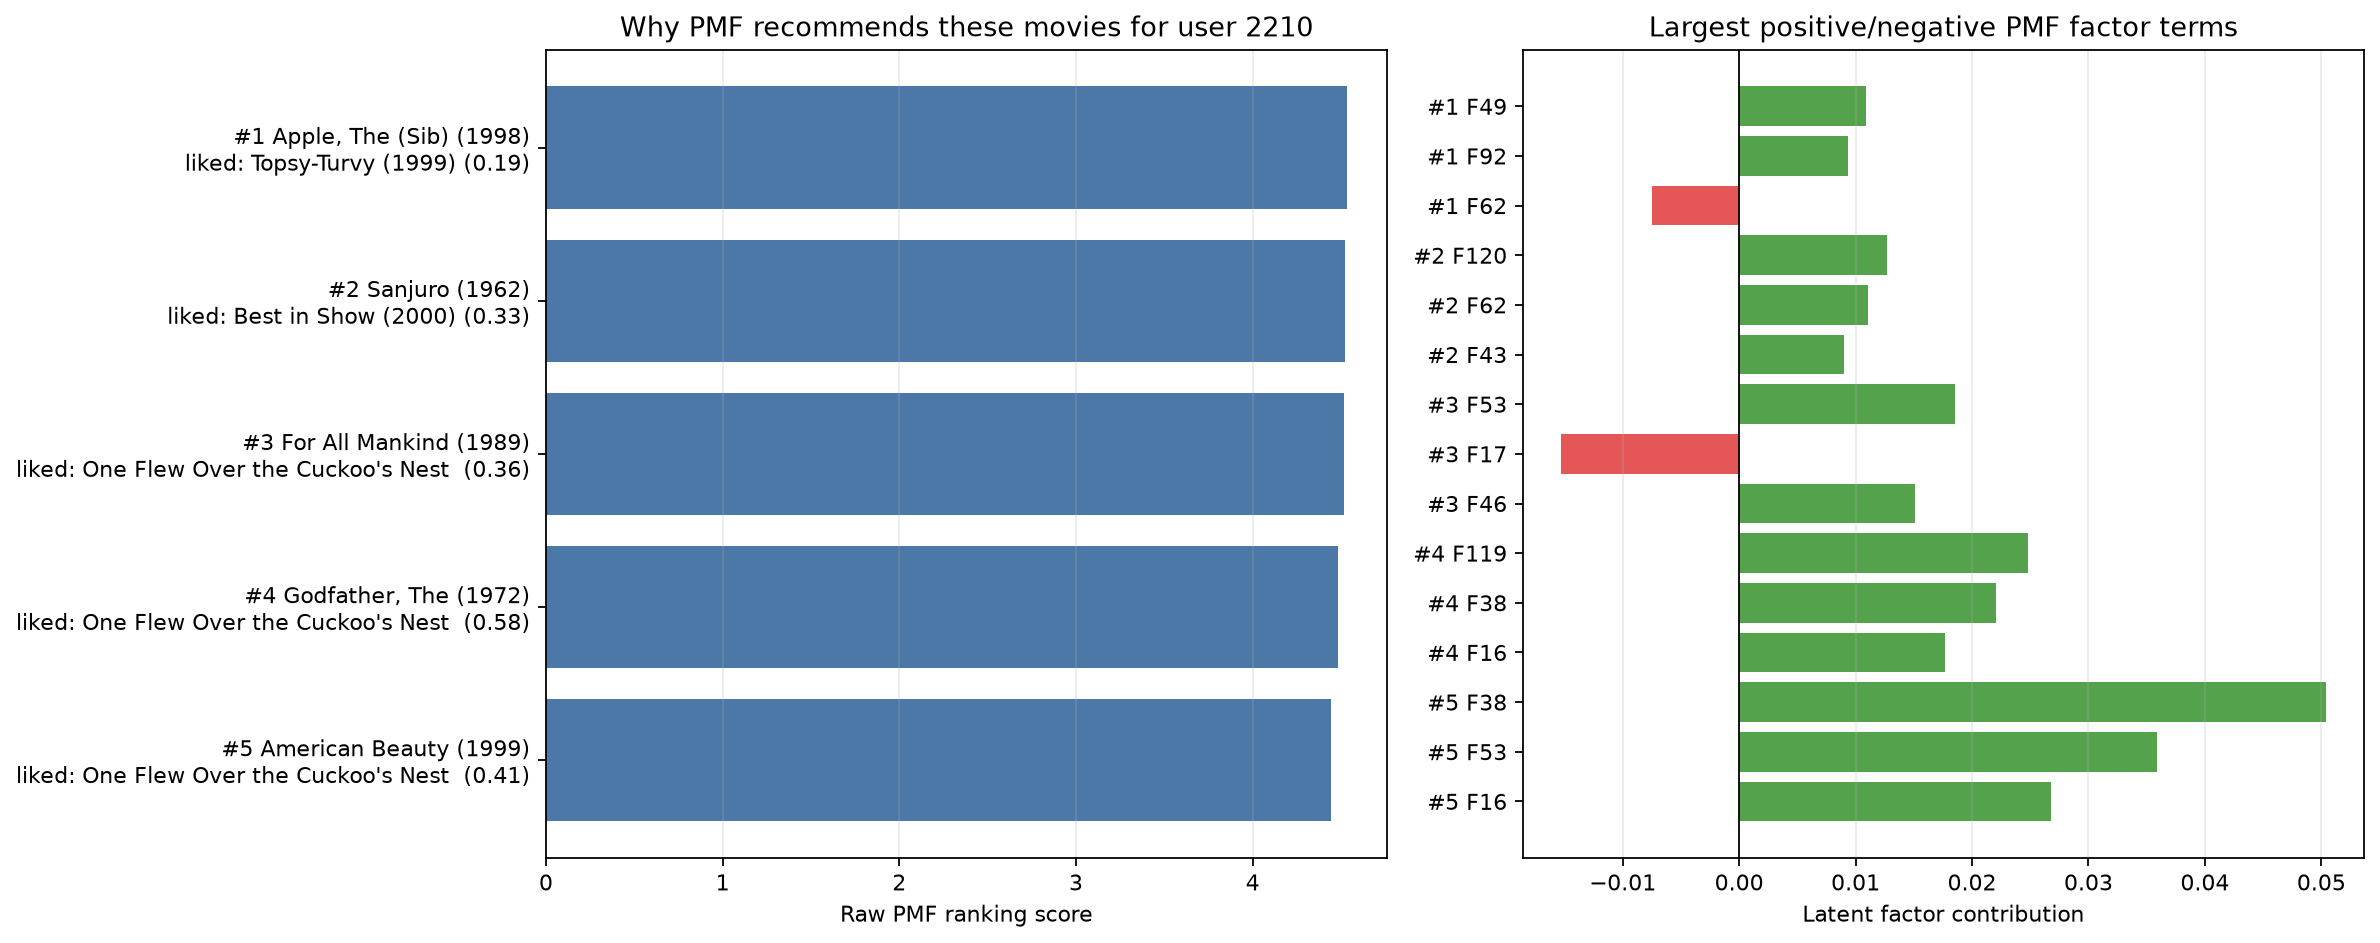

In [16]:
for selected in evaluated.itertuples(index=False):
    user_id = int(selected.user_id)
    explanations = pd.read_csv(
        REPORTS / f"user_{user_id}_explanations.csv"
    )
    print(
        f"User {user_id} max production explanation error:",
        explanations["reconstruction_error"].abs().max(),
    )
    display(explanations.head(3))
    display(Image(filename=str(REPORTS / f"user_{user_id}_explanation.png")))

## 17. Streamlit and artifact overview

Streamlit reads saved production recommendation artifacts and the two
evaluation protocols. The evaluation-profile selectbox synchronizes a
keyed manual user input through Session State; manual edits remain valid.

In [17]:
artifacts = [
    "bias_baseline_tuning.json", "item_knn_tuning.json",
    "model_metrics.json", "rmse_comparison.png",
    "ranking_protocol.json", "ranking_metrics.json",
    "ranking_results.csv", "ranking_comparison.png",
    "evaluated_users.json", "pmf_factor_interpretation.csv",
]
display(pd.DataFrame({
    "artifact": artifacts,
    "exists": [(REPORTS / name).exists() for name in artifacts],
}))

,artifact,exists
0,bias_baseline_tuning.json,True
1,item_knn_tuning.json,True
2,model_metrics.json,True
3,rmse_comparison.png,True
4,ranking_protocol.json,True
5,ranking_metrics.json,True
6,ranking_results.csv,True
7,ranking_comparison.png,True
8,evaluated_users.json,True
9,pmf_factor_interpretation.csv,True


## 18. Limitations

The models use collaborative ratings only and do not solve cold start.
RMSE and ranking metrics answer different questions. The temporal protocol
evaluates one known future positive and has no observed true negatives,
so unseen candidates cannot be interpreted as irrelevant. PMF factor
interpretations are descriptive, and the selected factor count remains at
the searched boundary.